In [4]:
import locale
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (chi2_contingency, kruskal, shapiro, spearmanr,ttest_ind)
import scikit_posthocs as sp
from IPython.display import Image, display

In [5]:
dff = pd.read_csv("medicore_cleaned.csv")

In [6]:
df = dff.copy()

In [7]:
df.head()

,Patient_Id,Visit_Id,Admission_Date,Department,Region,City,Patient_Age,Gender,Length_Of_Stay,Billing_Amount,Insurance_Type,Is_Emergency,Readmission,Satisfaction_Score
0,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19,Female,3,73041.40,Self-Pay,Scheduled,No,4
1,PAT101791,VIS107125,2024-10-06,General_Medicine,West,Pune,24,Male,2,16271.49,Private_Insurance,Scheduled,No,5
2,PAT100933,VIS103727,2024-05-23,Oncology,East,Kolkata,52,Male,3,74144.16,Corporate_Insurance,Scheduled,No,5
3,PAT101832,VIS107290,2025-11-09,Orthopedics,South,Kochi,39,Male,8,47344.12,Self-Pay,Scheduled,No,3
4,PAT102084,VIS108341,2025-02-06,Oncology,West,Pune,56,Male,7,69814.70,Corporate_Insurance,Emergency,No,5


In [8]:
df.describe()

,Patient_Age,Length_Of_Stay,Billing_Amount,Satisfaction_Score
count,10879.000000,10879.000000,10879.000000,10879.000000
mean,44.199375,3.278702,32028.245327,4.257193
std,17.859728,2.052827,20108.011172,0.775046
min,0.000000,1.000000,6624.950000,1.000000
25%,33.000000,2.000000,15188.885000,4.000000
50%,44.000000,3.000000,22201.360000,4.000000
75%,56.000000,4.000000,47972.875000,5.000000
max,95.000000,9.000000,98465.760000,5.000000


In [9]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], format="mixed")
df["Month&Year"] = df["Admission_Date"].dt.to_period("M")

In [10]:
# What is the overall patient volume and revenue, and how do they trend month-over-month?

# Which departments and regions generate the most revenue — and are any underperforming or overburdened?

# Is there a statistically significant difference in length of stay between Emergency and scheduled (non-Emergency) admissions?

# Does average length of stay differ significantly across departments?

# Is there a statistically significant association between department and readmission likelihood?

# Does insurance type correlate with billing amount or length of stay?

# Which patient segments (age group, gender) drive the most admissions and revenue?

# Which departments have the highest readmission rates, and is that hurting patient satisfaction?

# How does length of stay relate to billing amount and patient satisfaction?



In [11]:
#1 What is the overall patient volume and revenue, and how do they trend month-over-month?

In [12]:
total_patients = df['Patient_Id'].count()
unique_patients = df['Patient_Id'].nunique()
total_revenue = df['Billing_Amount'].sum().round(2)
locale.setlocale(locale.LC_ALL, 'en_IN')
revenue_format = locale.format_string("%0.2f", total_revenue, grouping=True)

In [13]:
print("Total Patients:",total_patients)
print("Unique patients:",unique_patients)
print("Total Revenue:", revenue_format)

Total Patients: 10879
Unique patients: 2993
Total Revenue: 34,84,35,280.91


In [14]:
grouped = (
    df.groupby(df["Month&Year"])
      .agg({
          "Patient_Id":"count",
          "Billing_Amount":"sum"
      })
)

grouped.index = grouped.index.strftime("%b %Y")

In [15]:
grouped

,Patient_Id,Billing_Amount
Month&Year,,
Jan 2024,397,12341428.85
Feb 2024,335,10356332.54
Mar 2024,364,10844118.59
Apr 2024,335,10541239.62
May 2024,354,11821529.98
Jun 2024,374,12542147.16
Jul 2024,577,19344373.91
Aug 2024,530,17278167.36
Sep 2024,540,16904028.40


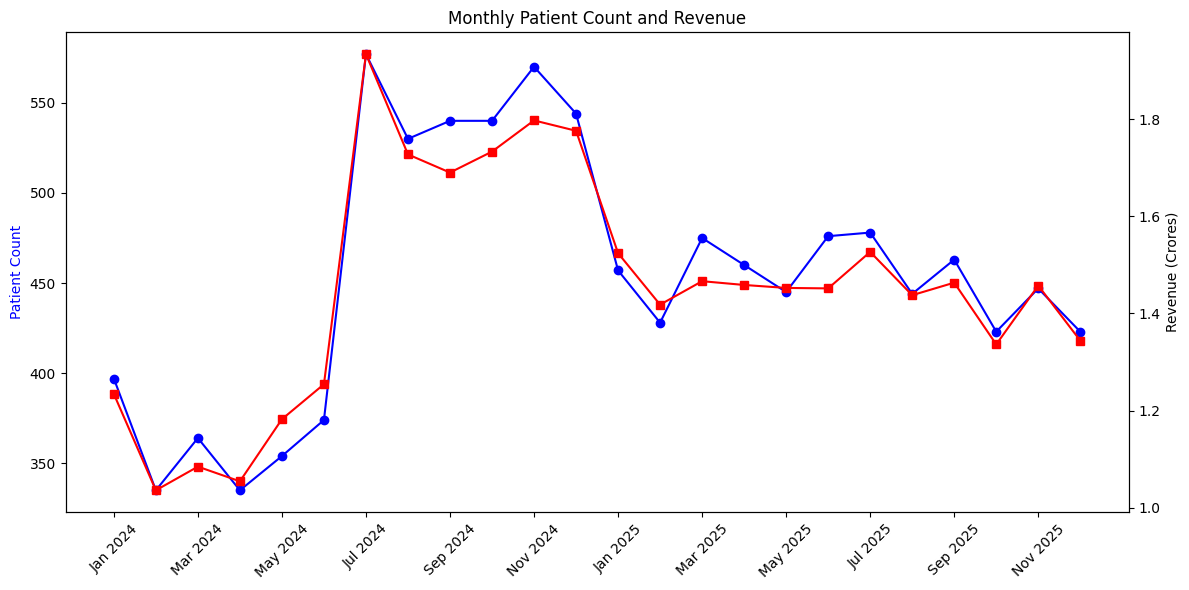

In [ ]:
df["Month&Year"] = df["Admission_Date"].dt.to_period("M")

# Group data
grouped = df.groupby("Month&Year").agg({
    "Patient_Id": "count",
    "Billing_Amount": "sum"
})
grouped["Revenue_Crores"] = grouped["Billing_Amount"] / 10000000       #this

grouped.index =                                       # check this

fig, ax1 = plt.subplots(figsize=(12,6))

# Left Y-axis
ax1.plot(grouped.index.astype(str), grouped["Patient_Id"], marker="o", color="blue")     # check this 
ax1.set_ylabel("Patient Count", color="blue")

# Right Y-axis
ax2 = ax1.twinx()
ax2.plot(grouped.index.astype(str), grouped["Revenue_Crores"], marker="s", color="red")
ax2.set_ylabel("Revenue (Crores)")

# Show every 2nd month on x-axis
months = grouped.index.astype(str)

ax1.set_xticks(range(0, len(months), 2))
ax1.set_xticklabels(months[::2], rotation=45)

plt.title("Monthly Patient Count and Revenue")
plt.tight_layout()
plt.show()

In [17]:
#2. Which departments and regions generate the most revenue — and are any underperforming or overburdened?

In [18]:
df.head()

,Patient_Id,Visit_Id,Admission_Date,Department,Region,City,Patient_Age,Gender,Length_Of_Stay,Billing_Amount,Insurance_Type,Is_Emergency,Readmission,Satisfaction_Score,Month&Year
0,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19,Female,3,73041.40,Self-Pay,Scheduled,No,4,2024-07
1,PAT101791,VIS107125,2024-10-06,General_Medicine,West,Pune,24,Male,2,16271.49,Private_Insurance,Scheduled,No,5,2024-10
2,PAT100933,VIS103727,2024-05-23,Oncology,East,Kolkata,52,Male,3,74144.16,Corporate_Insurance,Scheduled,No,5,2024-05
3,PAT101832,VIS107290,2025-11-09,Orthopedics,South,Kochi,39,Male,8,47344.12,Self-Pay,Scheduled,No,3,2025-11
4,PAT102084,VIS108341,2025-02-06,Oncology,West,Pune,56,Male,7,69814.70,Corporate_Insurance,Emergency,No,5,2025-02


In [19]:
departments = df.groupby("Department")["Billing_Amount"].sum() / 10000000

In [20]:
regions = df.groupby("Region")["Billing_Amount"].sum() / 10000000

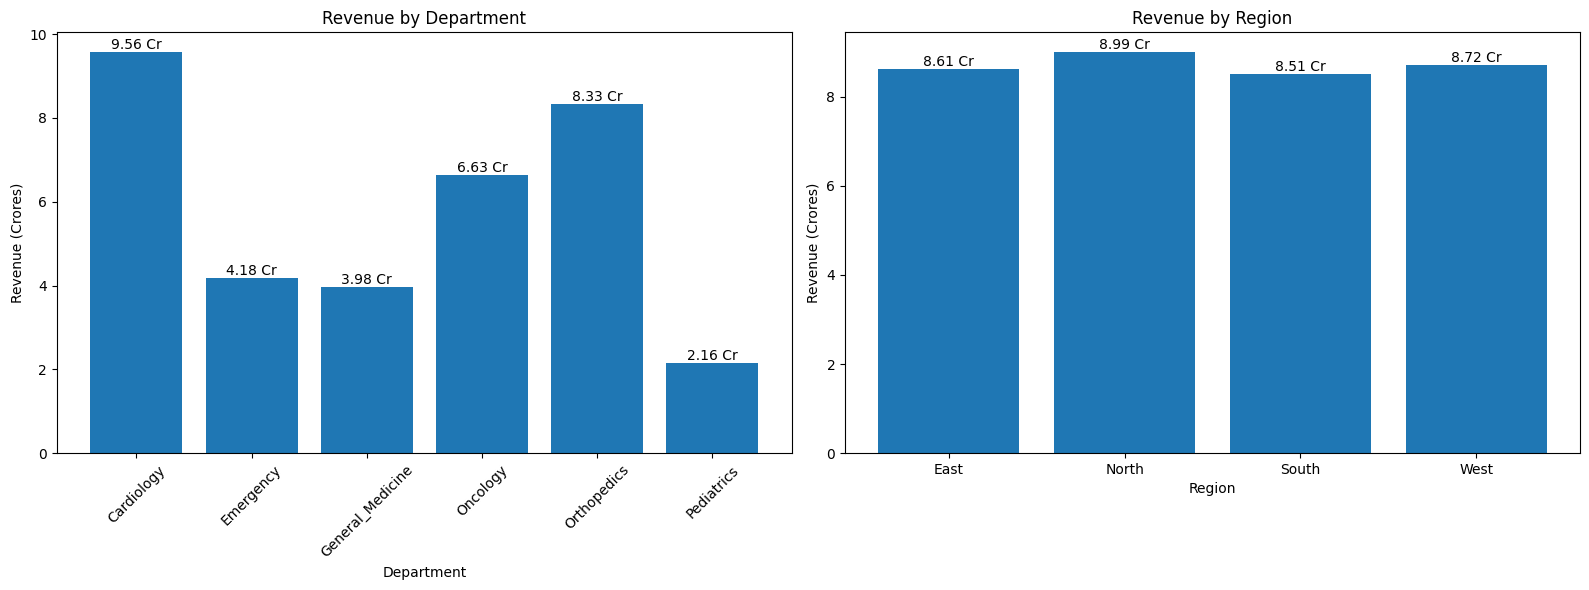

In [21]:
# Create two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# ---------------- Department ----------------
bars1 = ax1.bar(departments.index, departments.values)

ax1.set_title("Revenue by Department")
ax1.set_xlabel("Department")
ax1.set_ylabel("Revenue (Crores)")
ax1.tick_params(axis="x", rotation=45)

# Add labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f} Cr",
             ha="center",
             va="bottom")

# ---------------- Region ----------------
bars2 = ax2.bar(regions.index, regions.values)

ax2.set_title("Revenue by Region")
ax2.set_xlabel("Region")
ax2.set_ylabel("Revenue (Crores)")

# Add labels
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f} Cr",
             ha="center",
             va="bottom")

plt.tight_layout()
plt.show()

In [22]:
#3. Is there a statistically significant difference in length of stay between Emergency and scheduled (non-Emergency) admissions?

In [23]:
from scipy.stats import ttest_ind

emergency = df[df["Is_Emergency"] == "Emergency"]["Length_Of_Stay"]
scheduled = df[df["Is_Emergency"] == "Scheduled"]["Length_Of_Stay"]
t_stat, p_value = ttest_ind(emergency, scheduled, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)
alpha = 0.05

if p_value < alpha:
    print("======Result=====")
    print("Reject the Null Hypothesis")
    print("There is a significant difference in the average length of stay between Emergency and Scheduled patients.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant difference in the average length of stay between Emergency and Scheduled patients.")

T-statistic: -15.533022210602534
P-value: 2.4236662694125314e-53
======Result=====
Reject the Null Hypothesis
There is a significant difference in the average length of stay between Emergency and Scheduled patients.


In [24]:
#4. Does average length of stay differ significantly across departments?

In [25]:
from scipy.stats import shapiro

for dept in df["Department"].unique():
    data = df[df["Department"] == dept]["Length_Of_Stay"]
    stat, p = shapiro(data)

    print(f"{dept}")
    print("Statistic:", stat)
    print("P-value:", p)

    if p > 0.05:
        print("Normally Distributed\n")
    else:
        print("Not Normally Distributed\n")

print("So, the data is not normally distributed we use the Kruskal-Wallis Test")

Oncology
Statistic: 0.9537706819999839
P-value: 2.343716729065624e-16
Not Normally Distributed

General_Medicine
Statistic: 0.8670935936220733
P-value: 8.32948159506953e-42
Not Normally Distributed

Orthopedics
Statistic: 0.9445823970116097
P-value: 5.68376393957307e-26
Not Normally Distributed

Emergency
Statistic: 0.8396192243336037
P-value: 1.0053359081604798e-40
Not Normally Distributed

Pediatrics
Statistic: 0.8246813948985829
P-value: 2.858067469771347e-40
Not Normally Distributed

Cardiology
Statistic: 0.9549173654725918
P-value: 1.883360919862157e-23
Not Normally Distributed

So, the data is not normally distributed we use the Kruskal-Wallis Test


In [26]:
from scipy.stats import kruskal

groups = [
    group["Length_Of_Stay"].values
    for _, group in df.groupby("Department")
]

stat, p = kruskal(*groups)

print("Statistic:", stat)
print("P-value:", p)

"""hypotheses test:
H₀: The mean length of stay is the same across all departments.
H₁: At least one department has a different mean length of stay."""

if p < 0.05:
    print("Reject the Null Hypothesis")
    print("At least one department has the significantly difference.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No significant difference among departments.")

Statistic: 3218.0532987060715
P-value: 0.0
Reject the Null Hypothesis
At least one department has the significantly difference.


In [27]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    df,
    val_col="Length_Of_Stay",
    group_col="Department",
    p_adjust="bonferroni"
)
posthoc

,Cardiology,Emergency,General_Medicine,Oncology,Orthopedics,Pediatrics
Cardiology,1.000000e+00,0.000000e+00,1.834985e-220,7.413878e-02,4.256353e-10,4.345933e-304
Emergency,0.000000e+00,1.000000e+00,5.555094e-17,1.980259e-248,1.055153e-217,1.000000e+00
General_Medicine,1.834985e-220,5.555094e-17,1.000000e+00,2.487925e-173,2.384905e-134,1.157970e-16
Oncology,7.413878e-02,1.980259e-248,2.487925e-173,1.000000e+00,2.934403e-15,9.337393e-242
Orthopedics,4.256353e-10,1.055153e-217,2.384905e-134,2.934403e-15,1.000000e+00,1.666429e-208
Pediatrics,4.345933e-304,1.000000e+00,1.157970e-16,9.337393e-242,1.666429e-208,1.000000e+00


In [28]:
# First, I checked the assumptions for One-Way ANOVA. Since the data were not normally distributed, 
# I did not use ANOVA. Instead, I used the Kruskal-Wallis test, which is the appropriate non-parametric alternative. 
# The Kruskal-Wallis test showed a statistically significant difference among the departments (p < 0.05), 
# indicating that at least one department differs from the others. To identify which departments differed, 
# I performed Dunn's post hoc test. The results showed that most department pairs were significantly different. 
# Only Cardiology vs Oncology and Emergency vs Pediatrics were not significantly different. 
# Since this is a non-parametric analysis, the conclusions are based on the ranked data (distributions/medians) rather than 
# comparing group means.

In [29]:
df.groupby("Department")["Length_Of_Stay"].median()

Department
Cardiology          4.0
Emergency           2.0
General_Medicine    2.0
Oncology            5.0
Orthopedics         4.0
Pediatrics          2.0
Name: Length_Of_Stay, dtype: float64

In [30]:
#5. Is there a statistically significant association between department and readmission likelihood?

In [31]:
table = pd.crosstab(df["Department"], df["Readmission"])

print("Contingency Table:")
print(table)

# Step 2: Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

# Step 3: Expected Frequencies
expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print("\nExpected Frequencies:")
print(expected_df)

# Step 4: Check Chi-Square Assumption
if (expected >= 5).all():
    print("\nAssumption Satisfied: All expected frequencies are greater than or equal to 5.")
else:
    print("\nAssumption Violated: Some expected frequencies are less than 5.")

# Step 5: Hypothesis Test
alpha = 0.05

print("\nHypothesis Test:")

if p < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("Conclusion: There is a statistically significant association between Department and Readmission.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: There is no statistically significant association between Department and Readmission.")

Contingency Table:
Readmission         No  Yes
Department                 
Cardiology        1441  407
Emergency         1658  314
General_Medicine  2174  326
Oncology           706  208
Orthopedics       1620  256
Pediatrics        1555  214

Chi-Square Statistic: 125.78260386430662
P-value: 1.8673284325234417e-25
Degrees of Freedom: 5

Expected Frequencies:
Readmission                No         Yes
Department                               
Cardiology        1554.976744  293.023256
Emergency         1659.315011  312.684989
General_Medicine  2103.594080  396.405920
Oncology           769.073996  144.926004
Orthopedics       1578.536998  297.463002
Pediatrics        1488.503171  280.496829

Assumption Satisfied: All expected frequencies are greater than or equal to 5.

Hypothesis Test:
Reject the Null Hypothesis (H0)
Conclusion: There is a statistically significant association between Department and Readmission.


In [32]:
#6. Does insurance type correlate with billing amount or length of stay?

In [33]:
from scipy.stats import shapiro

for insurance in df["Insurance_Type"].unique():
    data = df[df["Insurance_Type"] == insurance]["Billing_Amount"]

    stat, p = shapiro(data)

    print(f"\n{insurance}")
    print("P-value:", p)

    if p > 0.05:
        print("Normally Distributed")
    else:
        print("Not Normally Distributed")

print("Data is not normally distributes we should use kurushals method")


Self-Pay
P-value: 4.477526556678981e-39
Not Normally Distributed

Private_Insurance
P-value: 1.5908866404624952e-45
Not Normally Distributed

Corporate_Insurance
P-value: 9.954625354712511e-34
Not Normally Distributed

Government_Scheme
P-value: 1.0046064611897283e-45
Not Normally Distributed
Data is not normally distributes we should use kurushals method


In [34]:
from scipy.stats import kruskal

groups = [
    group["Billing_Amount"].values
    for _, group in df.groupby("Insurance_Type")
]

stat, p = kruskal(*groups)

print("Statistic:", stat)
print("P-value:", p)

if p < 0.05:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in Billing Amount among Insurance Types.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference in Billing Amount among Insurance Types.")

Statistic: 1.3445055378146176
P-value: 0.7185928944626281
Fail to Reject the Null Hypothesis
There is no statistically significant difference in Billing Amount among Insurance Types.


In [35]:
#7. Which patient segments (age group, gender) drive the most admissions and revenue?

In [36]:
bins = [0, 18, 35, 50, 65, 120]
labels = ["0-18", "19-35", "36-50", "51-65", "66+"]

df["age_Group"] = pd.cut(df["Patient_Age"], bins=bins, labels=labels)

In [37]:
count_gender = df['Gender'].value_counts()
count_revenue = df.groupby('Gender')['Billing_Amount'].sum()

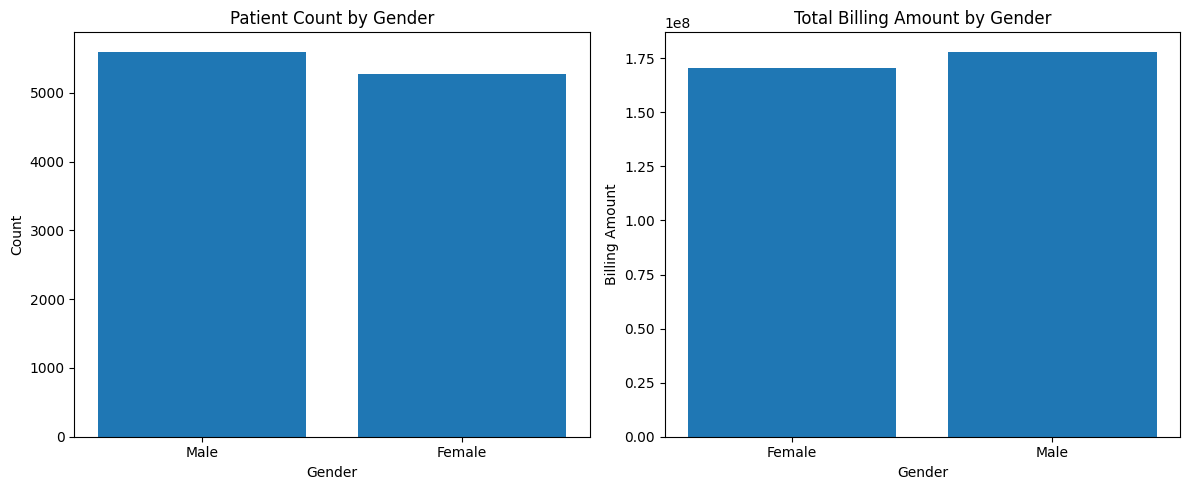

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(count_gender.index, count_gender.values)
ax[0].set_title("Patient Count by Gender")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Count")

ax[1].bar(count_revenue.index, count_revenue.values)
ax[1].set_title("Total Billing Amount by Gender")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Billing Amount")
plt.tight_layout()
plt.show()

In [39]:
#8. Which departments have the highest readmission rates, and is that hurting patient satisfaction?

In [40]:
readmission_rate = (
    df.groupby("Department")["Readmission"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

readmission_rate

Department
Oncology            22.757112
Cardiology          22.023810
Emergency           15.922921
Orthopedics         13.646055
General_Medicine    13.040000
Pediatrics          12.097230
Name: Readmission, dtype: float64

In [41]:
satisfaction = (
    df.groupby("Department")["Satisfaction_Score"]
      .mean()
      .sort_values(ascending=False)
)
satisfaction

Department
Pediatrics          4.431317
Emergency           4.411765
General_Medicine    4.367200
Orthopedics         4.167377
Cardiology          3.997294
Oncology            3.995624
Name: Satisfaction_Score, dtype: float64

In [42]:
result = pd.DataFrame({
    "Readmission_Rate (%)": df.groupby("Department")["Readmission"]
                              .apply(lambda x: (x == "Yes").mean() * 100),
    "Avg_Satisfaction": df.groupby("Department")["Satisfaction_Score"].mean()
})

result = result.sort_values("Readmission_Rate (%)", ascending=False)
result

,Readmission_Rate (%),Avg_Satisfaction
Department,,
Oncology,22.757112,3.995624
Cardiology,22.023810,3.997294
Emergency,15.922921,4.411765
Orthopedics,13.646055,4.167377
General_Medicine,13.040000,4.367200
Pediatrics,12.097230,4.431317


In [43]:
# Although the readmission rates differ across departments, there is no clear evidence from these summaries
# alone that higher readmission rates are associated with lower patient satisfaction.

In [44]:
#9. How does length of stay relate to billing amount and patient satisfaction?

In [45]:
from scipy.stats import shapiro

columns = ["Length_Of_Stay", "Billing_Amount", "Satisfaction_Score"]

for col in columns:
    stat, p = shapiro(df[col])

    print(f"\n{col}")
    print("P-value:", p)

    if p > 0.05:
        print("Normally Distributed")
    else:
        print("Not Normally Distributed")


Length_Of_Stay
P-value: 1.334953739097484e-66
Not Normally Distributed

Billing_Amount
P-value: 1.4024520184071692e-67
Not Normally Distributed

Satisfaction_Score
P-value: 5.777647888943813e-79
Not Normally Distributed


C:\Users\surya_t4rpfms\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10879.
  res = hypotest_fun_out(*samples, **kwds)


In [46]:
pairs = [
    ("Length_Of_Stay", "Billing_Amount"),
    ("Length_Of_Stay", "Satisfaction_Score")
]

alpha = 0.05

for x, y in pairs:
    corr, p = spearmanr(df[x], df[y])

    print(f"\n{x} vs {y}")
    print("Spearman Correlation:", round(corr, 3))
    print("P-value:", p)

    # Correlation Strength
    if abs(corr) < 0.20:
        strength = "Very Weak"
    elif abs(corr) < 0.40:
        strength = "Weak"
    elif abs(corr) < 0.60:
        strength = "Moderate"
    elif abs(corr) < 0.80:
        strength = "Strong"
    else:
        strength = "Very Strong"

    # Correlation Direction
    if corr > 0:
        direction = "Positive"
    elif corr < 0:
        direction = "Negative"
    else:
        direction = "No"

    print(f"Correlation: {strength} {direction}")

    # Hypothesis Decision
    if p < alpha:
        print("Reject the Null Hypothesis")
        print("There is a statistically significant correlation.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print("There is no statistically significant correlation.")


Length_Of_Stay vs Billing_Amount
Spearman Correlation: 0.621
P-value: 0.0
Correlation: Strong Positive
Reject the Null Hypothesis
There is a statistically significant correlation.

Length_Of_Stay vs Satisfaction_Score
Spearman Correlation: -0.337
P-value: 5.921649810500933e-288
Correlation: Weak Negative
Reject the Null Hypothesis
There is a statistically significant correlation.


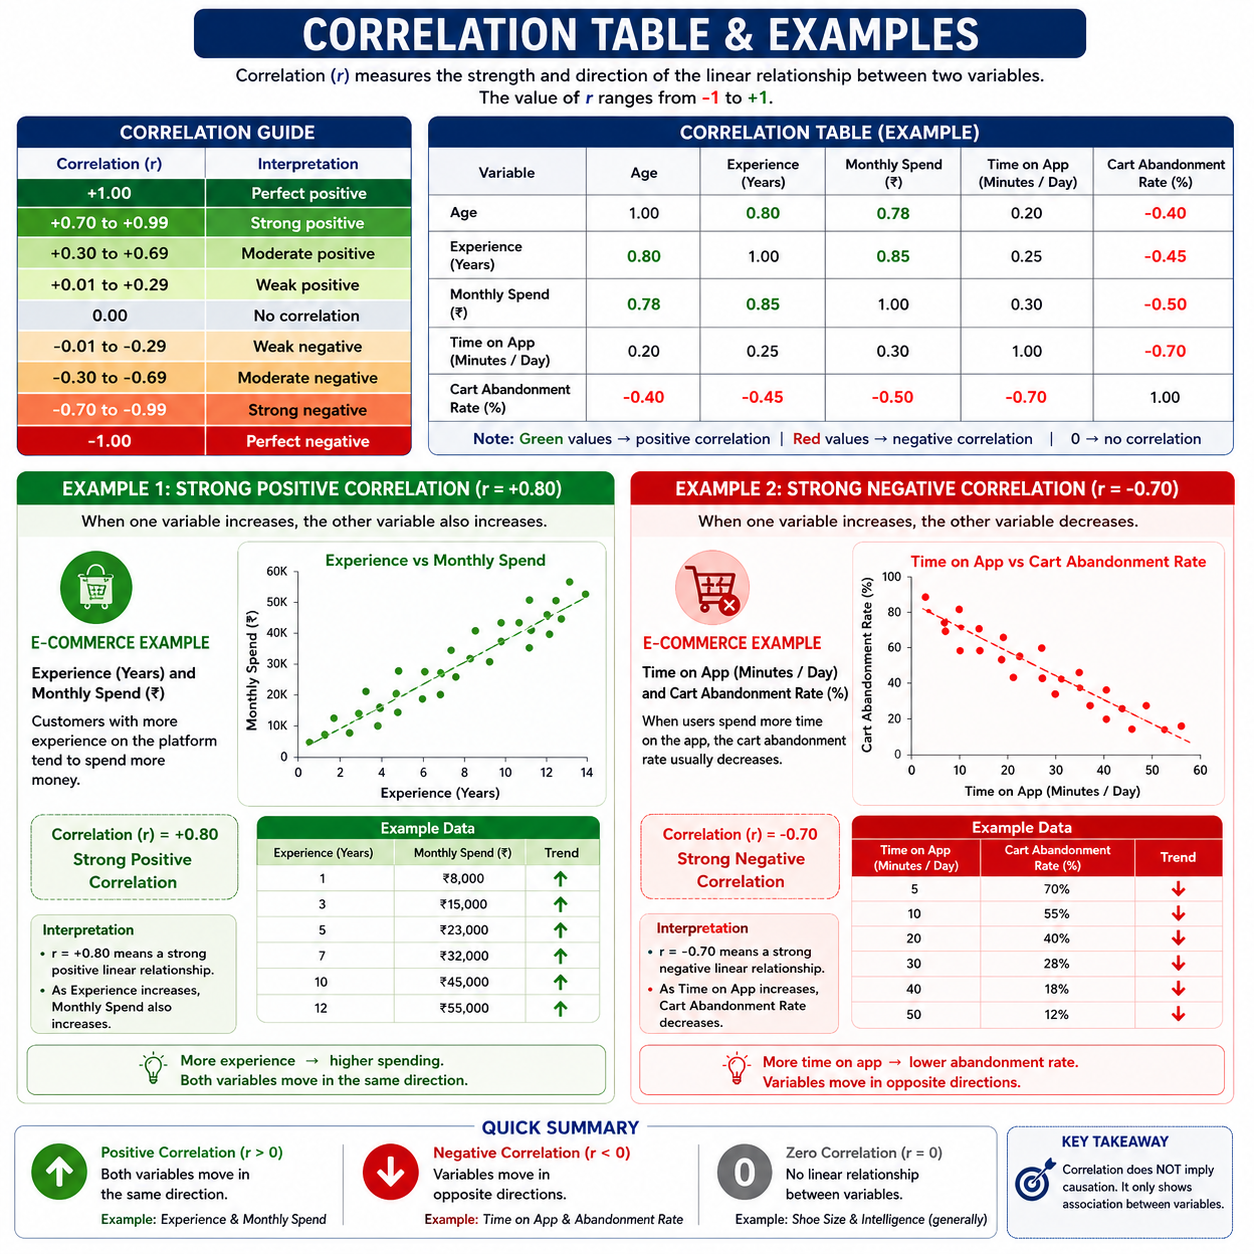

In [47]:
display(Image(filename=r"C:\Users\surya_t4rpfms\Downloads\ChatGPT Image Aug 5, 2026, 07_12_08 PM.png", width=600, height=500))

In [48]:
total_revenue = df["Billing_Amount"].sum()
total_patients = df["Patient_Id"].nunique()
total_visits = df["Visit_Id"].nunique()
avg_bill = df["Billing_Amount"].mean()
avg_los = df["Length_Of_Stay"].mean()
emergency_pct = (df["Is_Emergency"] == "Emergency").mean() * 100
readmission_pct = (df["Readmission"] == "Yes").mean() * 100
avg_satisfaction = df["Satisfaction_Score"].mean()
kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue (Rs)",
        "Total Patients",
        "Total Visits",
        "Average Billing (Rs)",
        "Average Length of Stay (Days)",
        "% Emergency Visits",
        "% Readmissions",
        "Average Satisfaction Score"
    ],
    "Value": [
        f"{total_revenue:,.2f}",
        f"{total_patients:,}",
        f"{total_visits:,}",
        f"{avg_bill:,.2f}",
        f"{avg_los:.2f}",
        f"{emergency_pct:.2f}%",
        f"{readmission_pct:.2f}%",
        f"{avg_satisfaction:.2f}"
    ]
})

kpi

,KPI,Value
0,Total Revenue (Rs),"348,435,280.91"
1,Total Patients,"2,993"
2,Total Visits,"10,879"
3,Average Billing (Rs),"32,028.25"
4,Average Length of Stay (Days),3.28
5,% Emergency Visits,26.82%
6,% Readmissions,15.86%
7,Average Satisfaction Score,4.26


In [49]:
region_summary = (
    df.groupby("Region")
      .agg(
          Total_Revenue=("Billing_Amount", "sum"),
          Avg_Billing=("Billing_Amount", "mean"),
          Avg_LOS=("Length_Of_Stay", "mean"),
          Avg_Satisfaction=("Satisfaction_Score", "mean"),
          Total_Visits=("Visit_Id", "count")
      )
)
region_summary

,Total_Revenue,Avg_Billing,Avg_LOS,Avg_Satisfaction,Total_Visits
Region,,,,,
East,86147593.02,31360.609035,3.168912,4.260648,2747
North,89941708.35,32481.657042,3.336222,4.263272,2769
South,85144782.43,32251.811527,3.298485,4.262121,2640
West,87201197.11,32023.943118,3.311788,4.242747,2723


In [50]:
dept_summary = (
    df.groupby("Department")
      .agg(
          Total_Revenue=("Billing_Amount", "sum"),
          Avg_Billing=("Billing_Amount", "mean"),
          Avg_LOS=("Length_Of_Stay", "mean"),
          Avg_Satisfaction=("Satisfaction_Score", "mean"),
          Total_Visits=("Visit_Id", "count")
      )
)
dept_summary

,Total_Revenue,Avg_Billing,Avg_LOS,Avg_Satisfaction,Total_Visits
Department,,,,,
Cardiology,95636402.54,51751.300076,4.681818,3.997294,1848
Emergency,41792220.80,21192.809736,2.157201,4.411765,1972
General_Medicine,39757536.96,15903.014784,2.602400,4.367200,2500
Oncology,66313764.13,72553.352440,5.036105,3.995624,914
Orthopedics,83307291.19,44406.871636,4.171109,4.167377,1876
Pediatrics,21628065.29,12226.153358,2.164500,4.431317,1769


In [51]:
best_region_revenue = region_summary["Total_Revenue"].idxmax()
best_region_satisfaction = region_summary["Avg_Satisfaction"].idxmax()
worst_region_satisfaction = region_summary["Avg_Satisfaction"].idxmin()

best_department_revenue = dept_summary["Total_Revenue"].idxmax()
best_department_satisfaction = dept_summary["Avg_Satisfaction"].idxmax()
worst_department_satisfaction = dept_summary["Avg_Satisfaction"].idxmin()

print(f"Highest revenue region          : {best_region_revenue}")
print(f"Highest satisfaction region     : {best_region_satisfaction}")
print(f"Lowest satisfaction region      : {worst_region_satisfaction}")

print(f"Highest revenue department      : {best_department_revenue}")
print(f"Highest satisfaction department : {best_department_satisfaction}")
print(f"Lowest satisfaction department  : {worst_department_satisfaction}")

Highest revenue region          : North
Highest satisfaction region     : North
Lowest satisfaction region      : West
Highest revenue department      : Cardiology
Highest satisfaction department : Pediatrics
Lowest satisfaction department  : Oncology


In [71]:
region = region_summary["Avg_Satisfaction"].idxmin()
value  = region_summary["Avg_Satisfaction"].min()

print("Worst Region:", region)
print("Satisfaction Score:", value)

Worst Region: West
Satisfaction Score: 4.242746970253397


In [52]:
df.head()

,Patient_Id,Visit_Id,Admission_Date,Department,Region,City,Patient_Age,Gender,Length_Of_Stay,Billing_Amount,Insurance_Type,Is_Emergency,Readmission,Satisfaction_Score,Month&Year,age_Group
0,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19,Female,3,73041.40,Self-Pay,Scheduled,No,4,2024-07,19-35
1,PAT101791,VIS107125,2024-10-06,General_Medicine,West,Pune,24,Male,2,16271.49,Private_Insurance,Scheduled,No,5,2024-10,19-35
2,PAT100933,VIS103727,2024-05-23,Oncology,East,Kolkata,52,Male,3,74144.16,Corporate_Insurance,Scheduled,No,5,2024-05,51-65
3,PAT101832,VIS107290,2025-11-09,Orthopedics,South,Kochi,39,Male,8,47344.12,Self-Pay,Scheduled,No,3,2025-11,36-50
4,PAT102084,VIS108341,2025-02-06,Oncology,West,Pune,56,Male,7,69814.70,Corporate_Insurance,Emergency,No,5,2025-02,51-65


In [53]:
df['Department'].value_counts()

Department
General_Medicine    2500
Emergency           1972
Orthopedics         1876
Cardiology          1848
Pediatrics          1769
Oncology             914
Name: count, dtype: int64

In [54]:
grouped["Billing_Amount"] = grouped["Billing_Amount"] / 10000000   

In [55]:
grouped

,Patient_Id,Billing_Amount,Revenue_Crores
Month&Year,,,
Jan 2024,397,1.234143,1.234143
Feb 2024,335,1.035633,1.035633
Mar 2024,364,1.084412,1.084412
Apr 2024,335,1.054124,1.054124
May 2024,354,1.182153,1.182153
Jun 2024,374,1.254215,1.254215
Jul 2024,577,1.934437,1.934437
Aug 2024,530,1.727817,1.727817
Sep 2024,540,1.690403,1.690403


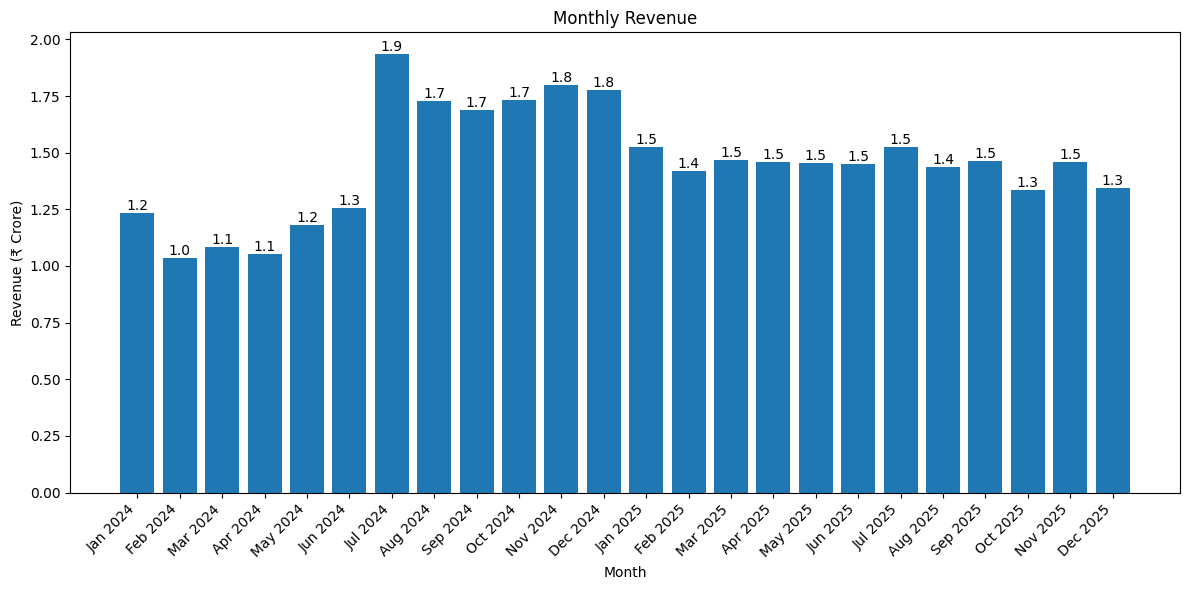

In [ ]:
monthly_revenue = df.groupby("Month&Year")["Billing_Amount"].sum()
monthly_revenue_crore = monthly_revenue / 1_00_00_000

# Convert PeriodIndex to string
x_labels = monthly_revenue_crore.index.strftime("%b %Y")  

plt.figure(figsize=(12,6))
bars = plt.bar(x_labels, monthly_revenue_crore.values)
plt.bar_label(bars, fmt="%.1f")

plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crore)")
plt.title("Monthly Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [64]:
monthly_revenue_crore

Month&Year
2024-01    1.234143
2024-02    1.035633
2024-03    1.084412
2024-04    1.054124
2024-05    1.182153
2024-06    1.254215
2024-07    1.934437
2024-08    1.727817
2024-09    1.690403
2024-10    1.733581
2024-11    1.797853
2024-12    1.776496
2025-01    1.524270
2025-02    1.418212
2025-03    1.466566
2025-04    1.458784
2025-05    1.452673
2025-06    1.451710
2025-07    1.526902
2025-08    1.437728
2025-09    1.463535
2025-10    1.336311
2025-11    1.457487
2025-12    1.344085
Freq: M, Name: Billing_Amount, dtype: float64

In [68]:
# df['Billing_Amount'].sum().apply(lambda x : format(x,",")) # Use .apply() only on Series/DataFrame, not scalars.

In [67]:
from babel.numbers import format_currency

total = df['Billing_Amount'].sum()

formatted = format_currency(total, 'INR', locale='en_IN')
print("Total Revenue:", formatted)


Total Revenue: ₹34,84,35,280.91


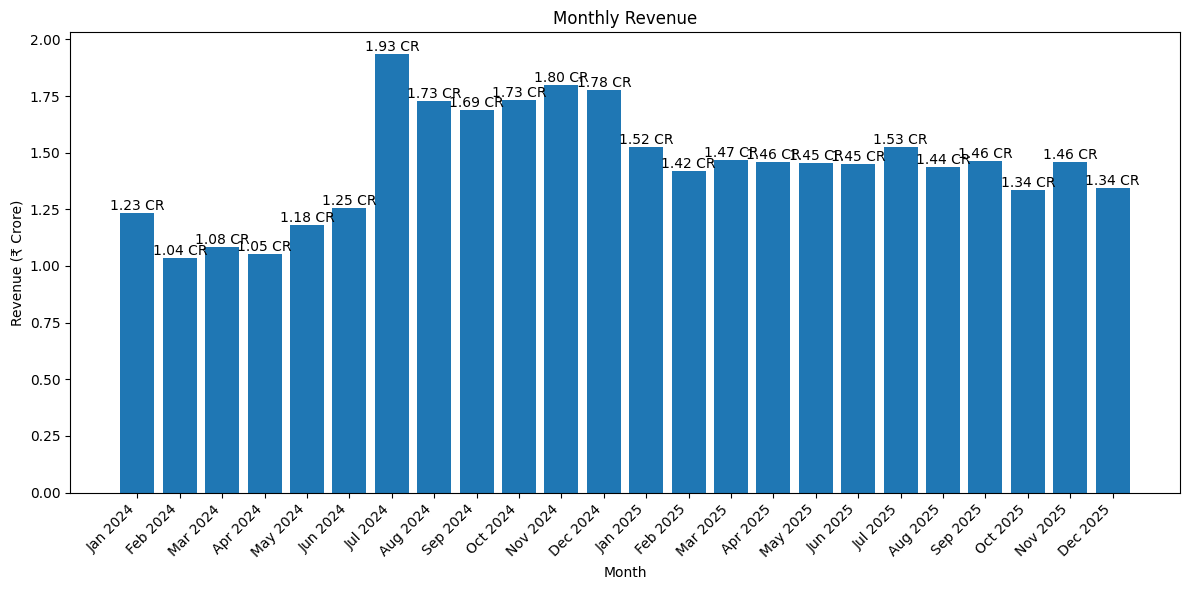

In [69]:
monthly_revenue = df.groupby("Month&Year")["Billing_Amount"].sum()
monthly_revenue_crore = monthly_revenue / 1_00_00_000

# Convert PeriodIndex to string
x_labels = monthly_revenue_crore.index.strftime("%b %Y")

plt.figure(figsize=(12,6))
bars = plt.bar(x_labels, monthly_revenue_crore.values)

# Data labels: 2 decimals + CR
plt.bar_label(bars, labels=[f"{value:.2f} CR" for value in monthly_revenue_crore.values])

plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crore)")
plt.title("Monthly Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

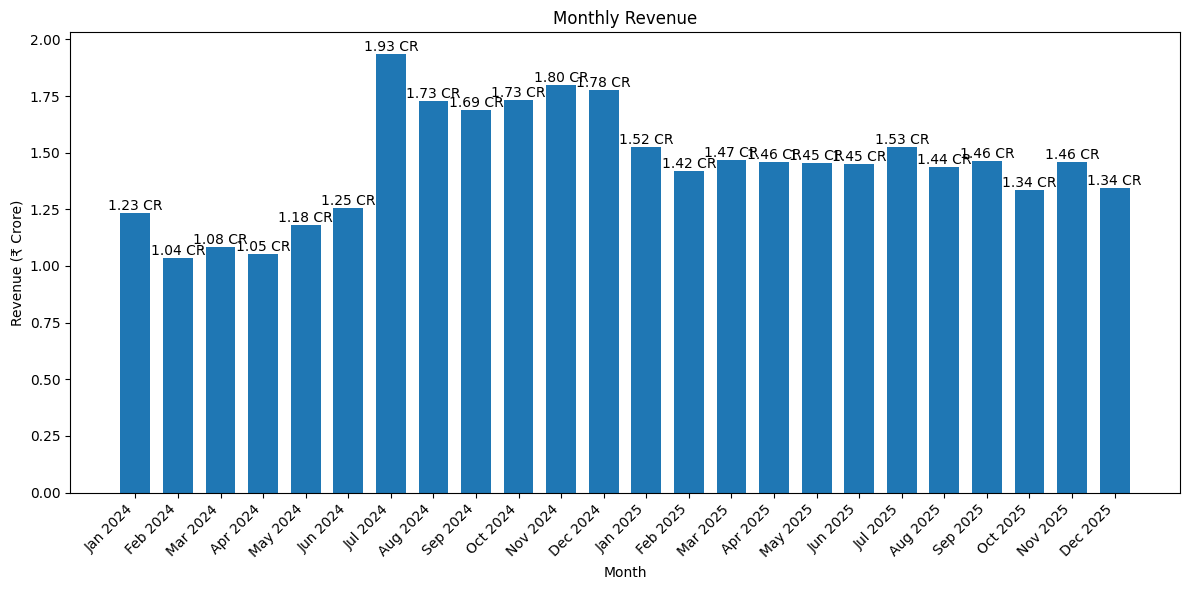

In [70]:
monthly_revenue = df.groupby("Month&Year")["Billing_Amount"].sum()
monthly_revenue_crore = monthly_revenue / 1_00_00_000

x_labels = monthly_revenue_crore.index.strftime("%b %Y")

plt.figure(figsize=(12,6))

bars = plt.bar(
    x_labels,
    monthly_revenue_crore.values,
    width=0.7
)

plt.bar_label(
    bars,
    labels=[f"{value:.2f} CR" for value in monthly_revenue_crore.values]
)

plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crore)")
plt.title("Monthly Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()